| **BO2: Permet aux professionnels et aux entreprises de planifier la reconversion et les formations adaptées** | Estimer le % de risque d’automatisation pour chaque métier. | Regression | Random Forest Regressor|

# **Random Forest Regressor**

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score,RandomizedSearchCV,GridSearchCV
from sklearn.preprocessing import  LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [31]:
df_scaled = pd.read_csv(r"C:\Users\meria\Desktop\ING\mlProject\prepared_data.csv")
df_scaled.head()
df_small = df_scaled.sample(n=3000, random_state=42)

print(df_small.shape)
df_small.head()

(3000, 15)


,Job_Title,Industry,Job_Status,AI_Impact_Level,Median_Salary_USD,Experience_Required_Years,Remote_Work_Ratio_%,Automation_Risk_%,Location,Gender_Diversity_%,Job_Growth_Rate_%,Growth_Category,Job_Value_Index,Vulnerability_Index,Education_Level
6252,"scientist, clinical (histocompatibility and im...",-1.078032,increasing,-1.210893,-1.057682,1.156252,-0.172350,-1.360229,-0.205817,1.072572,-0.209313,growth,0.070152,-0.871285,-1.434703
4684,"designer, furniture",1.541518,increasing,0.011244,0.422219,0.990866,1.149626,0.797423,-0.640489,1.182851,-0.114514,growth,-0.192322,-0.569928,0.002515
1731,risk manager,-0.641440,increasing,-1.210893,-0.120876,-1.324550,1.055719,1.082481,1.098198,-1.633603,0.012633,growth,-0.791476,-0.406231,-1.434703
4742,lexicographer,-1.078032,decreasing,-1.210893,0.304378,-0.828390,-0.024039,0.803996,1.532870,0.953632,0.792300,growth,-0.286626,0.551784,0.002515
4521,public affairs consultant,-0.204849,decreasing,-1.210893,-1.318452,0.494705,-0.084334,-0.272581,-1.509832,0.144724,-0.350519,decline,-0.831573,-0.133307,-0.716094


**Target Encoding of Categorical Features**

In [32]:
def target_encode(df, column, target):
    mean_map = df.groupby(column)[target].mean()
    return df[column].map(mean_map)
target = "Automation_Risk_%"
X = df_small.drop(columns=[target])
y = df_small[target]

num_cols = X.select_dtypes(include=["float64","int64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Num cols:", num_cols)
print("Cat cols:", cat_cols)

X_encoded = X.copy()

for col in cat_cols:
    X_encoded[col] = target_encode(df_small, col, target)

print("Final encoded shape:", X_encoded.shape)

Num cols: ['Industry', 'AI_Impact_Level', 'Median_Salary_USD', 'Experience_Required_Years', 'Remote_Work_Ratio_%', 'Location', 'Gender_Diversity_%', 'Job_Growth_Rate_%', 'Job_Value_Index', 'Vulnerability_Index', 'Education_Level']
Cat cols: ['Job_Title', 'Job_Status', 'Growth_Category']
Final encoded shape: (3000, 14)


**Train/Test split**

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (2400, 14), Test set: (600, 14)


**Grid Search for Random Forest Hyperparameters**

In [34]:
rf = RandomForestRegressor(random_state=42)
param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="r2",
    cv=3,
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)
print("Best parameters found:\n", grid_search.best_params_)

Fitting 3 folds for each of 288 candidates, totalling 864 fits
Best parameters found:
 {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}


**Evaluate Model on Test Set**

In [35]:
rf_model = grid_search.best_estimator_
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

**Calculate metrics for Random Forest**

In [36]:

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n RANDOM FOREST PERFORMANCE:")
print(f"MSE  : {mse_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"MAE  : {mae_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")


 RANDOM FOREST PERFORMANCE:
MSE  : 0.0765
RMSE : 0.2766
MAE  : 0.2241
R²   : 0.9251


**Feature Importances**

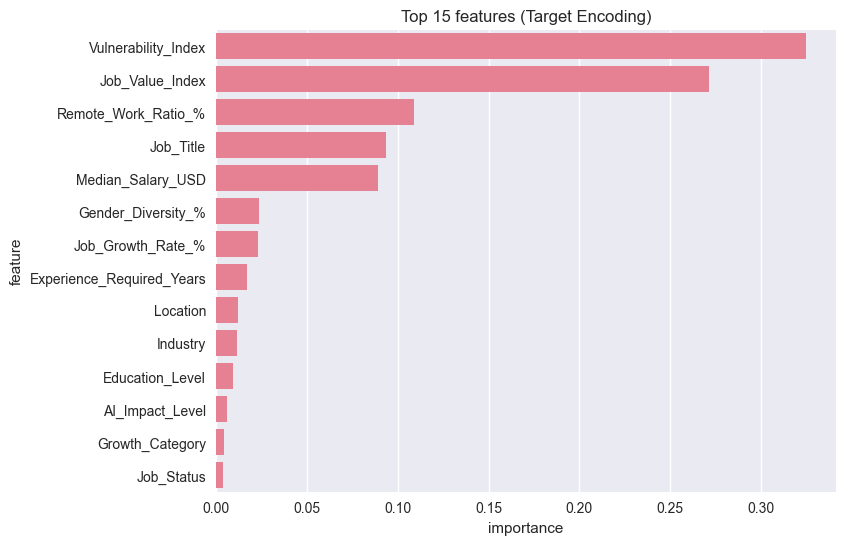

In [37]:
importances_rf = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=importances_rf.head(15), x="importance", y="feature")
plt.title("Top 15 features (Target Encoding)")
plt.show()

**Correlation matrix**

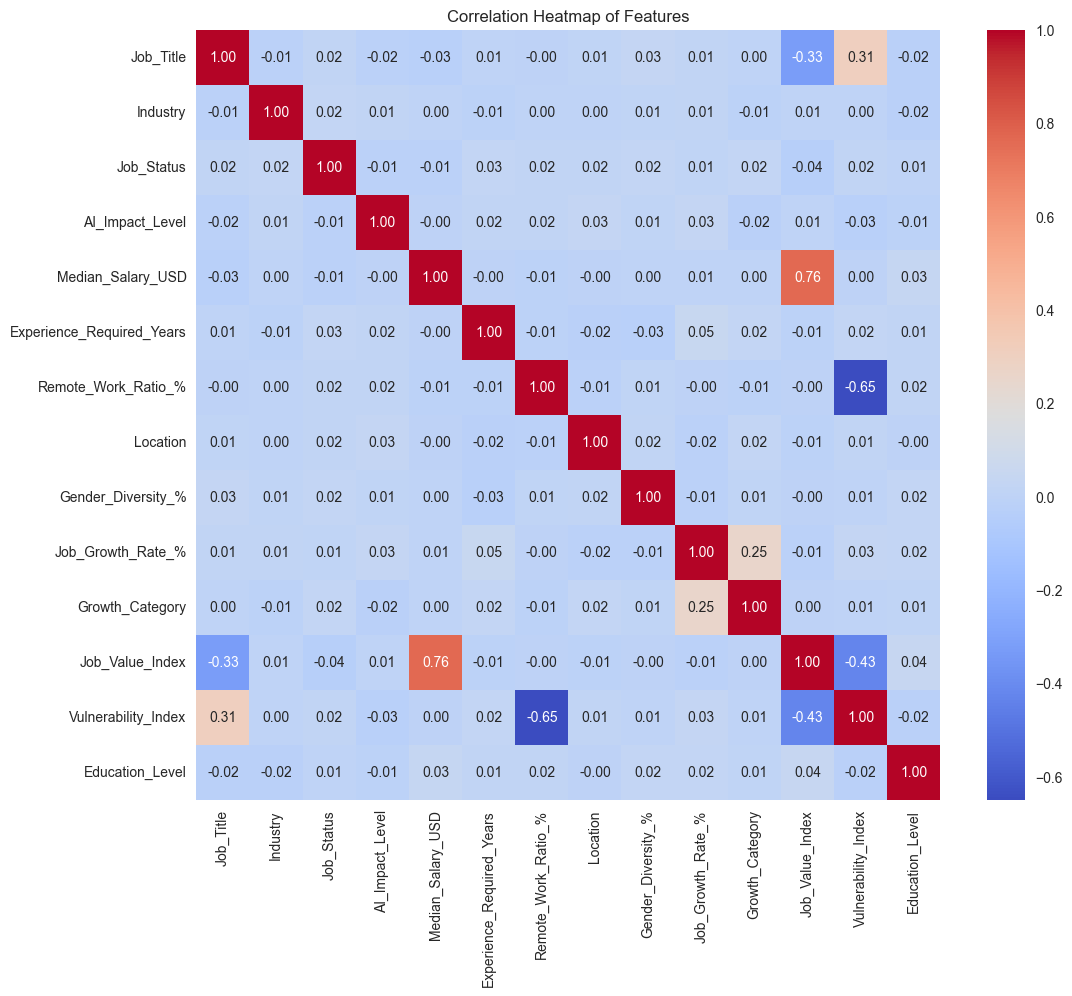

In [38]:

corr_matrix = X_encoded.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of Features")
plt.show()

**learning_curve**

In [39]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X_encoded, y, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1, random_state=42)

**Calculate means and standard deviations**

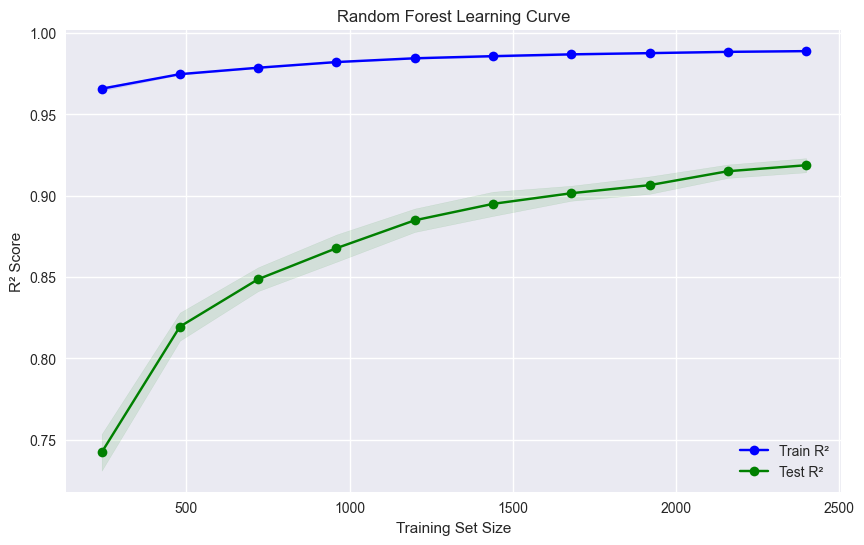

In [40]:

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Train R²")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Test R²")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="green")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Random Forest Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

**Moyenne du risque par métier**


Top 20 métiers les plus à risque :
Job_Title
technical brewer                    1.664013
museum/gallery curator              1.629072
tax adviser                         1.628034
solicitor                           1.616964
forensic psychologist               1.454544
trading standards officer           1.346436
general practice doctor             1.345398
housing manager/officer             1.330523
broadcast journalist                1.308036
production assistant, television    1.213767
phytotherapist                      1.202869
quarry manager                      1.170005
theatre stage manager               1.166545
optician, dispensing                1.158589
teaching laboratory technician      1.141637
sports therapist                    1.135843
administrator                       1.103353
conservator, museum/gallery         1.100124
merchant navy officer               1.086978
adult guidance worker               1.053076
Name: Automation_Risk_%, dtype: float64


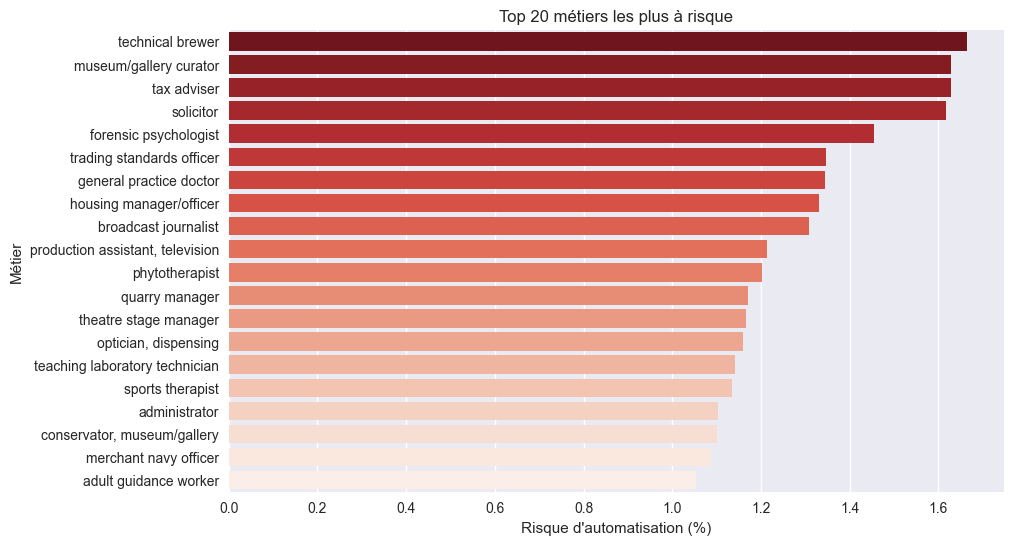

In [41]:
top_jobs = df_small.groupby("Job_Title")["Automation_Risk_%"].mean().sort_values(ascending=False).head(20)
print("Top 20 métiers les plus à risque :")
print(top_jobs)
plt.figure(figsize=(10,6))
sns.barplot(x=top_jobs.values, y=top_jobs.index, palette="Reds_r")
plt.xlabel("Risque d'automatisation (%)")
plt.ylabel("Métier")
plt.title("Top 20 métiers les plus à risque")
plt.show()

# **XGboost**

 **Train/Test split**

In [42]:

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)
params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'alpha': 0.1,
    'lambda': 1.0,
    'random_state': 42
}

**Initialize and train XGBoost**

In [43]:
xgb_model = xgb.XGBRegressor(**params)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


**Make predictions**

In [44]:
y_pred_xgb = xgb_model.predict(X_test)

**Calculate metrics**

In [45]:
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance:")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")
print(f"R² Score: {r2_xgb:.4f}")

XGBoost Performance:
RMSE: 0.1019
MAE: 0.0713
R² Score: 0.9898


**Feature Importance for XGBoost**

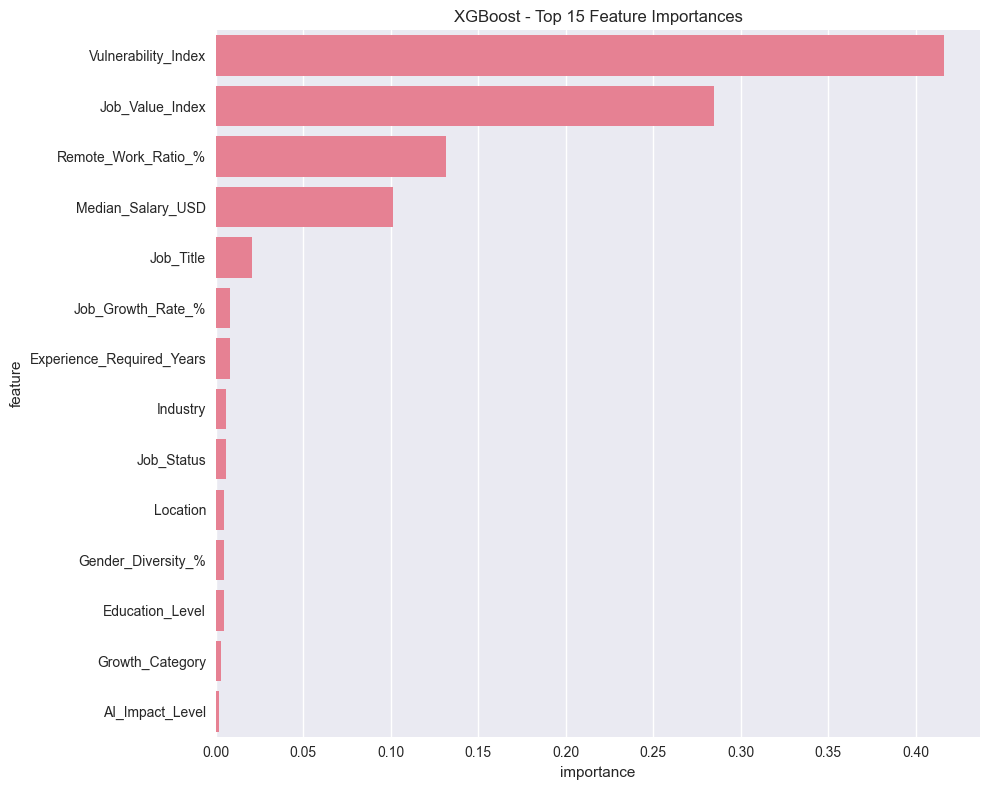

In [46]:
importances_xgb = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances_xgb.head(15), x="importance", y="feature")
plt.title("XGBoost - Top 15 Feature Importances")
plt.tight_layout()
plt.show()

# **COMPARISON**

**VISUALIZATION**


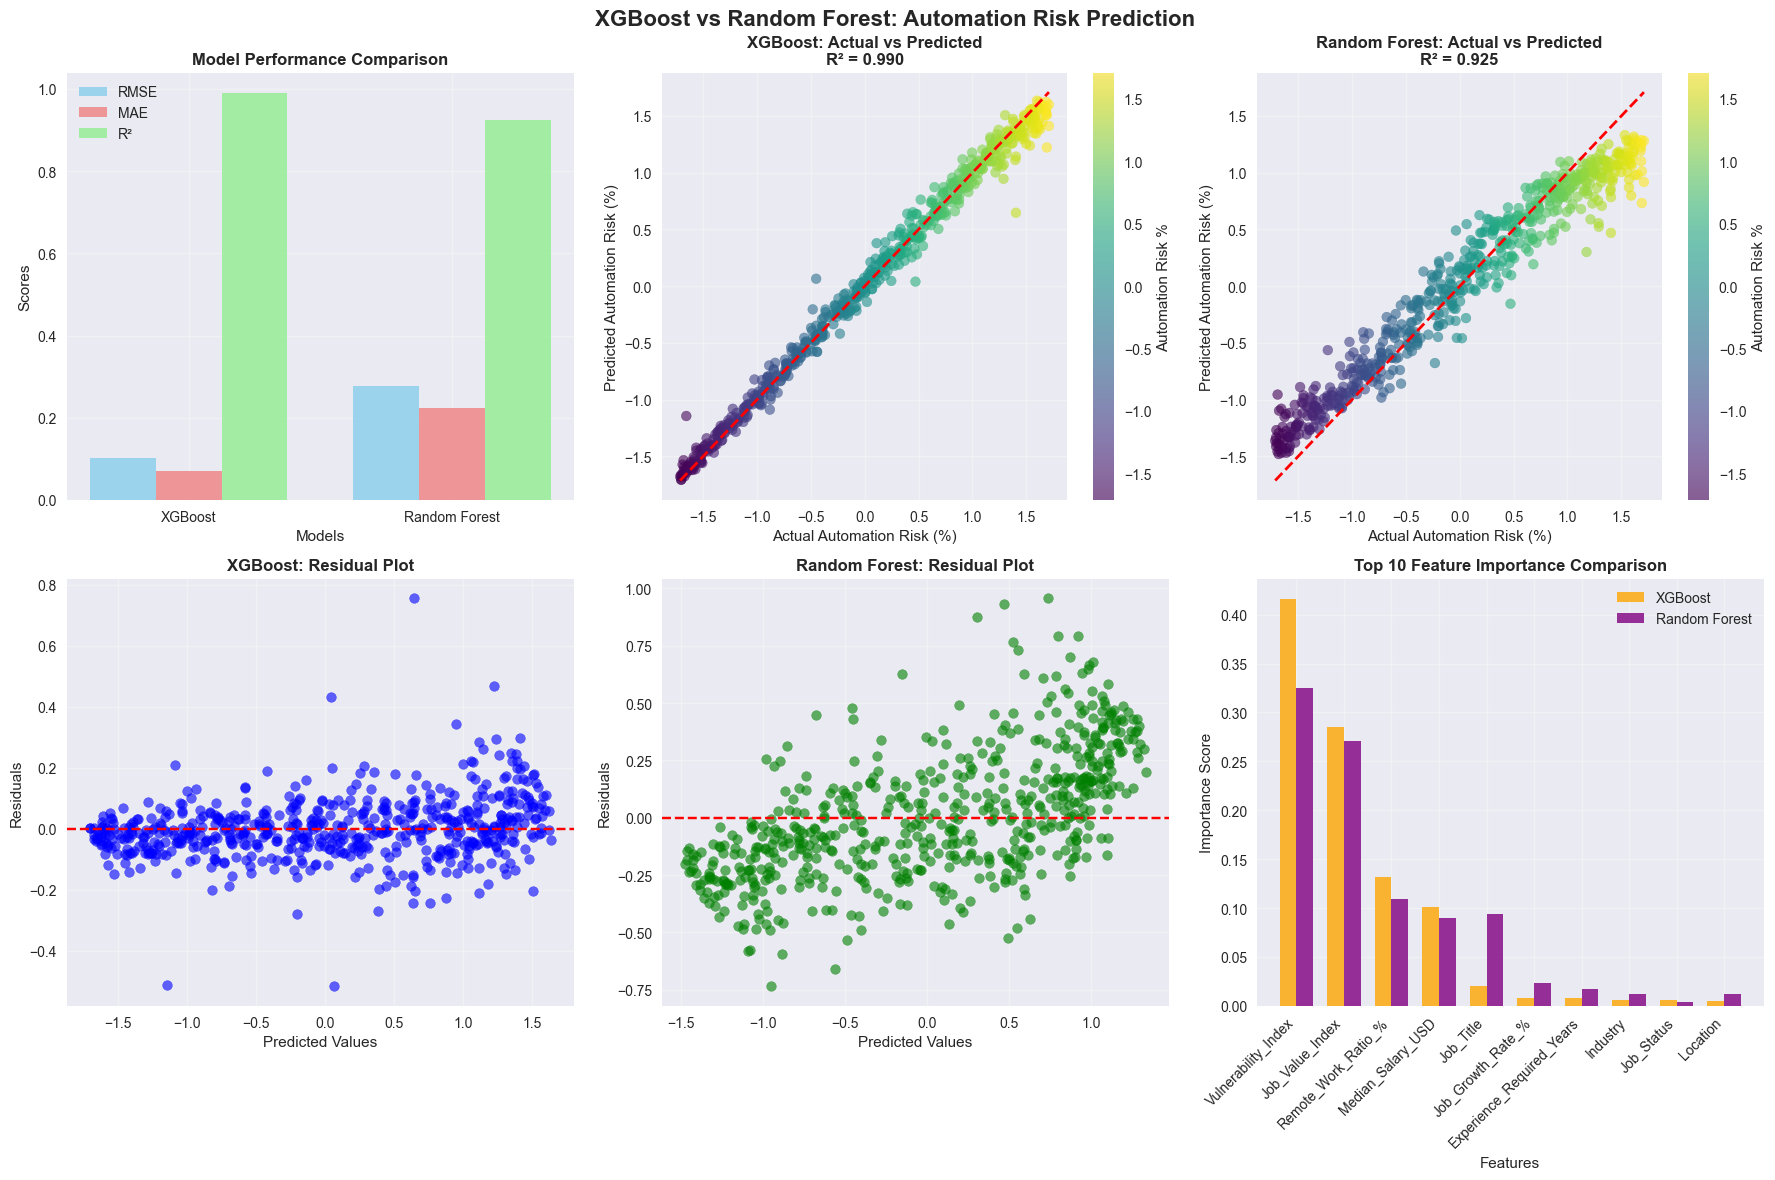

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('XGBoost vs Random Forest: Automation Risk Prediction', fontsize=16, fontweight='bold')

metrics_comparison = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest'],
    'RMSE': [rmse_xgb, rmse_rf],
    'MAE': [mae_xgb, mae_rf],
    'R²': [r2_xgb, r2_rf]
})

ax1 = axes[0, 0]
x_pos = np.arange(len(metrics_comparison))
width = 0.25

ax1.bar(x_pos - width, metrics_comparison['RMSE'], width, label='RMSE', alpha=0.8, color='skyblue')
ax1.bar(x_pos, metrics_comparison['MAE'], width, label='MAE', alpha=0.8, color='lightcoral')
ax1.bar(x_pos + width, metrics_comparison['R²'], width, label='R²', alpha=0.8, color='lightgreen')

ax1.set_xlabel('Models')
ax1.set_ylabel('Scores')
ax1.set_title('Model Performance Comparison', fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(metrics_comparison['Model'])
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Actual vs Predicted - XGBoost
ax2 = axes[0, 1]
scatter1 = ax2.scatter(y_test, y_pred_xgb, alpha=0.6, c=y_test, cmap='viridis', s=50)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Automation Risk (%)')
ax2.set_ylabel('Predicted Automation Risk (%)')
ax2.set_title(f'XGBoost: Actual vs Predicted\nR² = {r2_xgb:.3f}', fontweight='bold')
plt.colorbar(scatter1, ax=ax2, label='Automation Risk %')
ax2.grid(True, alpha=0.3)

# 3. Actual vs Predicted - Random Forest
ax3 = axes[0, 2]
scatter2 = ax3.scatter(y_test, y_pred_rf, alpha=0.6, c=y_test, cmap='viridis', s=50)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax3.set_xlabel('Actual Automation Risk (%)')
ax3.set_ylabel('Predicted Automation Risk (%)')
ax3.set_title(f'Random Forest: Actual vs Predicted\nR² = {r2_rf:.3f}', fontweight='bold')
plt.colorbar(scatter2, ax=ax3, label='Automation Risk %')
ax3.grid(True, alpha=0.3)

# 4. Residual Plot - XGBoost
ax4 = axes[1, 0]
residuals_xgb = y_test - y_pred_xgb
ax4.scatter(y_pred_xgb, residuals_xgb, alpha=0.6, color='blue')
ax4.axhline(y=0, color='red', linestyle='--')
ax4.set_xlabel('Predicted Values')
ax4.set_ylabel('Residuals')
ax4.set_title('XGBoost: Residual Plot', fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. Residual Plot - Random Forest
ax5 = axes[1, 1]
residuals_rf = y_test - y_pred_rf
ax5.scatter(y_pred_rf, residuals_rf, alpha=0.6, color='green')
ax5.axhline(y=0, color='red', linestyle='--')
ax5.set_xlabel('Predicted Values')
ax5.set_ylabel('Residuals')
ax5.set_title('Random Forest: Residual Plot', fontweight='bold')
ax5.grid(True, alpha=0.3)

# 6. Feature Importance - Combined
ax6 = axes[1, 2]

# Get feature importances
feature_importance_xgb = xgb_model.feature_importances_
feature_importance_rf = rf_model.feature_importances_

# Create DataFrame for comparison
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'XGBoost': feature_importance_xgb,
    'RandomForest': feature_importance_rf
})

# Sort by XGBoost importance and take top 10
importance_df = importance_df.sort_values('XGBoost', ascending=False).head(10)

x = np.arange(len(importance_df))
width = 0.35

ax6.bar(x - width/2, importance_df['XGBoost'], width, label='XGBoost', alpha=0.8, color='orange')
ax6.bar(x + width/2, importance_df['RandomForest'], width, label='Random Forest', alpha=0.8, color='purple')

ax6.set_xlabel('Features')
ax6.set_ylabel('Importance Score')
ax6.set_title('Top 10 Feature Importance Comparison', fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(importance_df['Feature'], rotation=45, ha='right')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Cross-Validation Comparison**

In [48]:

from sklearn.model_selection import cross_val_score


cv_scores_xgb = cross_val_score(xgb_model, X_encoded, y, cv=5, scoring='r2')
cv_scores_rf = cross_val_score(rf_model, X_encoded, y, cv=5, scoring='r2')

print(f"\nCROSS-VALIDATION RESULTS:")
print(f"XGBoost Cross-Validation R²: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std() * 2:.4f})")
print(f"Random Forest Cross-Validation R²: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std() * 2:.4f})")


CROSS-VALIDATION RESULTS:
XGBoost Cross-Validation R²: 0.9903 (+/- 0.0052)
Random Forest Cross-Validation R²: 0.9187 (+/- 0.0087)


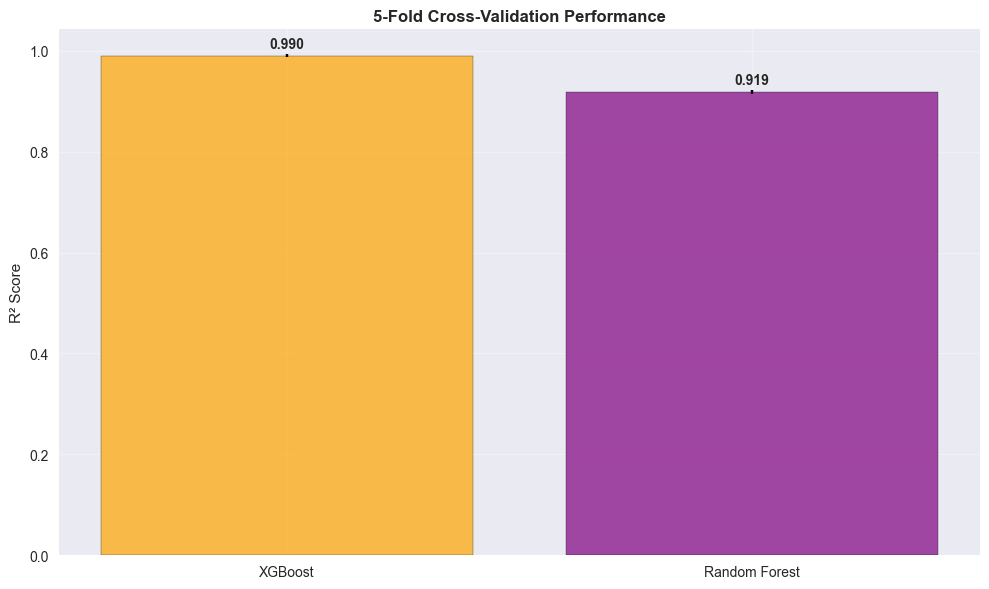

In [49]:

plt.figure(figsize=(10, 6))
models = ['XGBoost', 'Random Forest']
cv_means = [cv_scores_xgb.mean(), cv_scores_rf.mean()]
cv_stds = [cv_scores_xgb.std(), cv_scores_rf.std()]

bars = plt.bar(models, cv_means, yerr=cv_stds, capsize=10, alpha=0.7, 
               color=['orange', 'purple'], edgecolor='black')

plt.ylabel('R² Score')
plt.title('5-Fold Cross-Validation Performance', fontweight='bold')
plt.grid(True, alpha=0.3)


for bar, value in zip(bars, cv_means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()


**Final Summary**

In [50]:

results_summary = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R²', 'CV R² Mean', 'CV R² Std'],
    'XGBoost': [rmse_xgb, mae_xgb, r2_xgb, cv_scores_xgb.mean(), cv_scores_xgb.std()],
    'Random Forest': [rmse_rf, mae_rf, r2_rf, cv_scores_rf.mean(), cv_scores_rf.std()]
})

print("\nFINAL COMPARISON SUMMARY:")
print(results_summary.round(4))

if r2_xgb > r2_rf:
    best_model = "XGBoost"
    improvement = ((r2_xgb - r2_rf) / r2_rf) * 100
else:
    best_model = "Random Forest"
    improvement = ((r2_rf - r2_xgb) / r2_xgb) * 100

print(f"\nBEST MODEL: {best_model}")
print(f"Improvement over other model: {abs(improvement):.2f}%")


FINAL COMPARISON SUMMARY:
       Metric  XGBoost  Random Forest
0        RMSE   0.1019         0.2766
1         MAE   0.0713         0.2241
2          R²   0.9898         0.9251
3  CV R² Mean   0.9903         0.9187
4   CV R² Std   0.0026         0.0043

BEST MODEL: XGBoost
Improvement over other model: 6.99%


In [51]:
print(" BUSINESS INSIGHTS - BO2: Planification Reconversion & Formation")

print(f"\n PRÉDICTION DU RISQUE D'AUTOMATISATION:")
print(f" Performance globale: R² = {max(r2_xgb, r2_rf):.3f}")
print(f" Erreur moyenne: {min(mae_xgb, mae_rf):.1f}% points")
print(f" Modèle recommandé: {best_model}")

print(f"\n FACTEURS CLÉS INFLUENÇANT L'AUTOMATISATION:")
top_features = importances_rf.head(5) if best_model == "Random Forest" else importances_xgb.head(5)
for i, row in top_features.iterrows():
    feature_name = row['feature']
    importance = row['importance']
    if 'Remote_Work' in feature_name:
        interpretation = "Télétravail → Impact significatif sur l'automatisation"
    elif 'Automation_Vulnerability' in feature_name:
        interpretation = "Vulnérabilité → Métiers non-télétravaillables à haut risque"
    elif 'Salary' in feature_name:
        interpretation = "Salaire → Métiers bien payés souvent moins automatisables"
    elif 'Experience' in feature_name:
        interpretation = "Expérience → Expertise réduit le risque d'automatisation"
    elif 'Education' in feature_name:
        interpretation = "Éducation → Niveau d'étude corrélé avec la résistance à l'IA"
    else:
        interpretation = "Facteur structurel important"
    
    print(f"  • {feature_name}: {importance:.3f} - {interpretation}")


 BUSINESS INSIGHTS - BO2: Planification Reconversion & Formation

 PRÉDICTION DU RISQUE D'AUTOMATISATION:
 Performance globale: R² = 0.990
 Erreur moyenne: 0.1% points
 Modèle recommandé: XGBoost

 FACTEURS CLÉS INFLUENÇANT L'AUTOMATISATION:
  • Vulnerability_Index: 0.416 - Facteur structurel important
  • Job_Value_Index: 0.285 - Facteur structurel important
  • Remote_Work_Ratio_%: 0.132 - Télétravail → Impact significatif sur l'automatisation
  • Median_Salary_USD: 0.101 - Salaire → Métiers bien payés souvent moins automatisables
  • Job_Title: 0.021 - Facteur structurel important
